In [1]:
pip install -q torchmetrics

In [2]:
# Imports
import random

import matplotlib.pyplot as plt
import numpy as np
import sklearn

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from torchmetrics import Accuracy

In [3]:
# Reproducibilty
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    # For CUDA
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(45)
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
# Load dataset and convert labels to 0-based indexing
data = sklearn.datasets.fetch_covtype(random_state=45)
x, y = data.data, data.target - 1

# --- Preprocessing ---
# Split dataset into train, val, test
x_train_full, x_test, y_train_full, y_test = train_test_split(x, y, stratify=y,
                                                              test_size=0.2, random_state=45)
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, stratify=y_train_full,
                                                  test_size=0.15, random_state=45)


# Scale dataset (standard scaler)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

# Delete redundant datasets
del x_train_full, y_train_full, x_train, x_val, x_test

# Convert to PyTorch tensors
x_train_tensor = torch.tensor(x_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
x_val_tensor = torch.tensor(x_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
x_test_tensor = torch.tensor(x_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create TensorDataset object
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

In [5]:
# Create Dataloader
g = torch.Generator()   #for deterministic DataLoader shuffling
g.manual_seed(45)
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=g, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [6]:
# Model definition
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, output_dim):
        super().__init__()
        self.fc1= nn.Linear(input_dim, hidden_dim1)
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.fc3 = nn.Linear(hidden_dim2, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Instantiate model, optimizer, and metrics
model = MLP(input_dim=54, hidden_dim1=128, hidden_dim2=96, output_dim=7).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
train_accuracy = Accuracy(task='multiclass', num_classes=7).to(device)
val_accuracy = Accuracy(task='multiclass', num_classes=7).to(device)

In [7]:
# Training & Evaluation Functions
def train_one_epoch(model, data_loader, optimizer, accuracy_metric, device):
    model.train()
    epoch_loss = 0
    accuracy_metric.reset()
    for input, target in data_loader:
        input, target = input.to(device), target.to(device)

        # Forward
        logits = model(input)
        loss = F.cross_entropy(logits, target)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss = (epoch_loss) + loss / len(data_loader)
        preds = torch.argmax(logits, dim=1)
        accuracy_metric.update(preds, target)

    train_accuracy = accuracy_metric.compute()

    return epoch_loss.item(), train_accuracy.item()

# Validation
def evaluate(model, data_loader, accuracy_metric, device):
    model.eval()
    with torch.no_grad():
        val_loss = 0
        for input, target in data_loader:
              input, target = input.to(device), target.to(device)
              logits = model(input)
              preds = torch.argmax(logits, dim=1)

              accuracy_metric.update(preds, target)
              loss = F.cross_entropy(logits, target)
              val_loss = val_loss + loss / len(data_loader)

        overall_accuracy = accuracy_metric.compute()
    return val_loss.item(), overall_accuracy.item()


In [8]:
# Training loop
num_epochs = 100
train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, train_accuracy, device)
    val_loss, val_acc = evaluate(model, val_loader, val_accuracy, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if (epoch % 5 == 0) or (epoch == num_epochs -1):
        print(f'Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | '
              f'Train Acc: {train_acc:.3f}% | Val Acc: {val_acc:.3f}%')

Epoch 001 | Train Loss: 0.5592 | Val Loss: 0.4641 | Train Acc: 0.761% | Val Acc: 0.803%
Epoch 006 | Train Loss: 0.3278 | Val Loss: 0.3301 | Train Acc: 0.864% | Val Acc: 0.843%
Epoch 011 | Train Loss: 0.2830 | Val Loss: 0.2813 | Train Acc: 0.885% | Val Acc: 0.859%
Epoch 016 | Train Loss: 0.2600 | Val Loss: 0.2722 | Train Acc: 0.895% | Val Acc: 0.867%
Epoch 021 | Train Loss: 0.2474 | Val Loss: 0.2594 | Train Acc: 0.900% | Val Acc: 0.874%
Epoch 026 | Train Loss: 0.2370 | Val Loss: 0.2594 | Train Acc: 0.906% | Val Acc: 0.879%
Epoch 031 | Train Loss: 0.2289 | Val Loss: 0.2328 | Train Acc: 0.908% | Val Acc: 0.882%
Epoch 036 | Train Loss: 0.2229 | Val Loss: 0.2377 | Train Acc: 0.911% | Val Acc: 0.886%
Epoch 041 | Train Loss: 0.2197 | Val Loss: 0.2416 | Train Acc: 0.913% | Val Acc: 0.888%
Epoch 046 | Train Loss: 0.2132 | Val Loss: 0.2332 | Train Acc: 0.915% | Val Acc: 0.890%
Epoch 051 | Train Loss: 0.2102 | Val Loss: 0.2301 | Train Acc: 0.917% | Val Acc: 0.892%
Epoch 056 | Train Loss: 0.2081 |

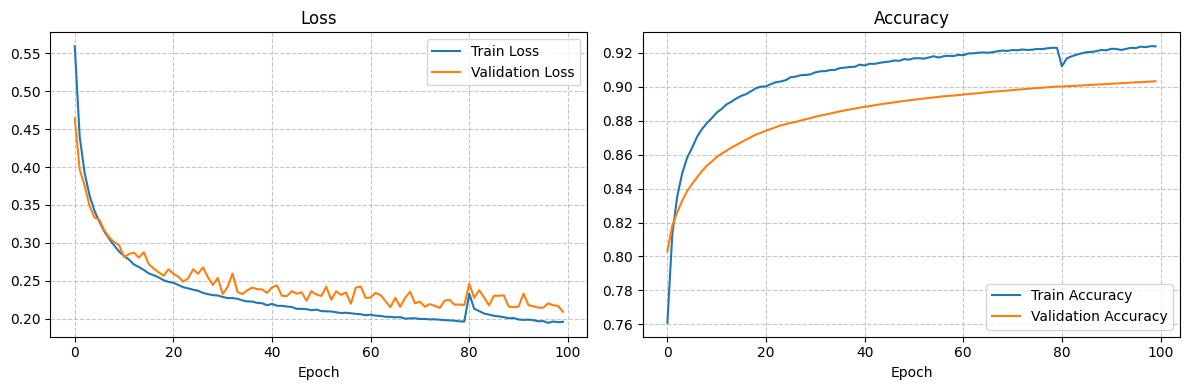

In [9]:
# Plot Learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot losses and accuracies on subplots
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Validation Loss')
axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(val_accs, label='Validation Accuracy')

for ax, title in zip(axes, ['Loss', 'Accuracy']):
    ax.set_xlabel('Epoch')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [10]:
# Check test accuracy
test_accuracy = Accuracy(task='multiclass', num_classes=7).to(device)
_, test_acc = evaluate(model, test_loader, test_accuracy, device)
print(f'Test Accuracy: {test_acc:.3f}%')

Test Accuracy: 0.919%
